In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!ls "/content/drive/MyDrive/Colab Notebooks/CodeAlpha/CodeAlpha_DiseasePrediction/data"

heart.data


In [ ]:
import pandas as pd
import numpy as np

file_path = "/content/drive/MyDrive/Colab Notebooks/CodeAlpha/CodeAlpha_DiseasePrediction/data/heart.data"

columns = [
    "age", "sex", "cp", "trestbps", "chol", "fbs",
    "restecg", "thalach", "exang", "oldpeak",
    "slope", "ca", "thal", "target"
]

df = pd.read_csv(file_path, names=columns)

df.head()



,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [ ]:
df.replace("?", np.nan, inplace=True)
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [ ]:
df = df.apply(pd.to_numeric)
df["target"] = df["target"].apply(lambda x: 1 if x > 0 else 0)
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [ ]:
# checking Missing Values
df.isnull().sum()
# there are 6 missing vals out of 303 row , best strategy is to drop these 6 rows
df = df.dropna()
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [ ]:
df["target"].value_counts()

,count
target,
0,160
1,137


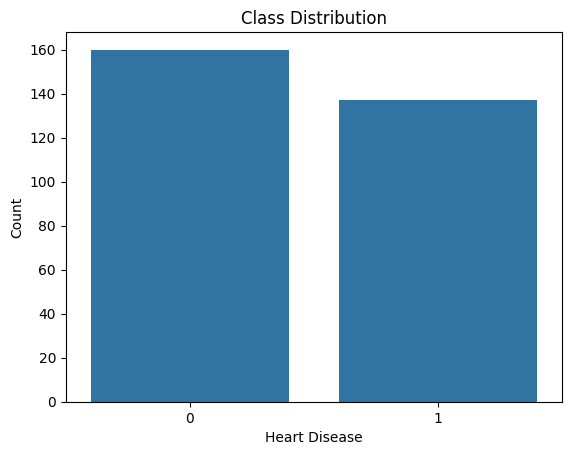

In [ ]:
import seaborn as sns

x = df.drop("target", axis=1)
y = df["target"]

sns.countplot(x=y)
plt.title("Class Distribution")
plt.xlabel("Heart Disease")
plt.ylabel("Count")
plt.show()

**The class distribution plot** shows that the dataset is relatively balanced between patients with heart disease and those without. Therefore, no additional class balancing techniques such as oversampling or undersampling were required.

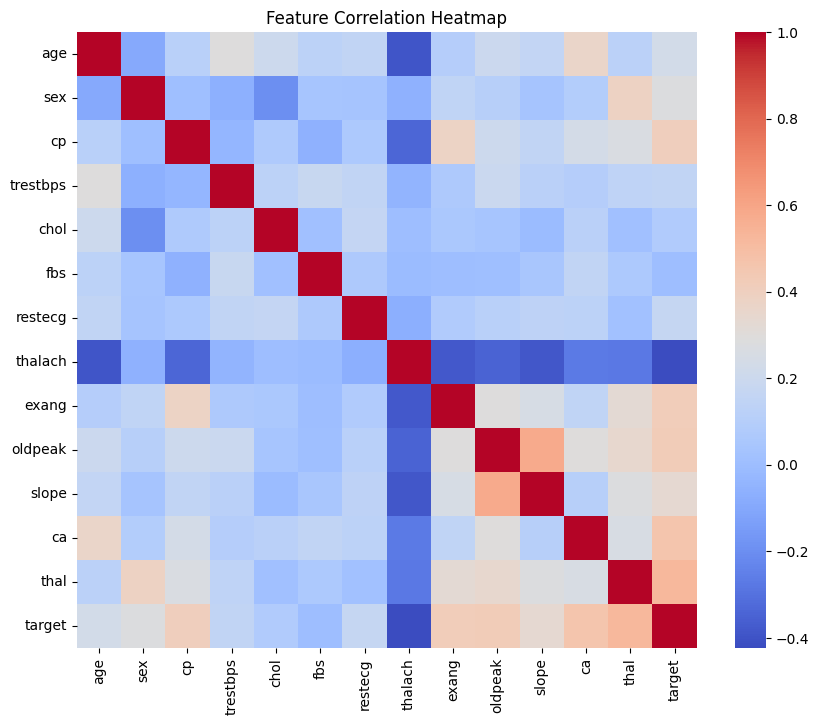

In [ ]:
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap="coolwarm", annot=False)

plt.title("Feature Correlation Heatmap")
plt.show()

**The correlation heatmap** illustrates the relationships between the different medical variables in the dataset. Most features show weak to moderate correlations with each other, which suggests that they provide independent information to the model. No extremely high correlations are observed, indicating that multicollinearity is limited in the dataset.

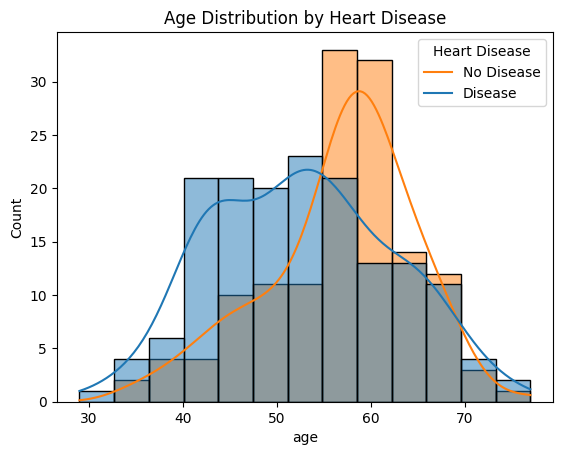

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(data=df, x="age", hue="target", kde=True)

plt.title("Age Distribution by Heart Disease")

# Change legend labels
plt.legend(title="Heart Disease", labels=["No Disease", "Disease"])

plt.show()

**The age distribution plot** suggests that patients diagnosed with heart disease tend to be older on average compared to patients without heart disease. This observation aligns with medical knowledge that age is a significant risk factor for cardiovascular diseases.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression


x_train, x_test, y_train, y_test = train_test_split(x, y, test_size= 0.2, random_state = 42, stratify=y) #stratify=y to keep class balance
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)



In [ ]:

# Train Logistic Regression
log_reg = LogisticRegression(max_iter=1000)

log_reg.fit(x_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Train Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(x_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

# Make Predictions
y_pred_log = log_reg.predict(x_test_scaled)
y_pred_rf = rf_model.predict(x_test)

# Evaluate Models

print("Logistic Regression Accuracy:",
      accuracy_score(y_test, y_pred_log))

print("\nLogistic Regression Report:")
print(classification_report(y_test, y_pred_log))

print("Random Forest Accuracy:",
      accuracy_score(y_test, y_pred_rf))

print("\nRandom Forest Report:")
print(classification_report(y_test, y_pred_rf))

Logistic Regression Accuracy: 0.8333333333333334

Logistic Regression Report:
              precision    recall  f1-score   support

           0       0.82      0.88      0.85        32
           1       0.85      0.79      0.81        28

    accuracy                           0.83        60
   macro avg       0.83      0.83      0.83        60
weighted avg       0.83      0.83      0.83        60

Random Forest Accuracy: 0.8666666666666667

Random Forest Report:
              precision    recall  f1-score   support

           0       0.85      0.91      0.88        32
           1       0.88      0.82      0.85        28

    accuracy                           0.87        60
   macro avg       0.87      0.86      0.87        60
weighted avg       0.87      0.87      0.87        60



**Logistic Regression** achieved 83% accuracy, correctly identifying most patients but with a few false negatives. **Random Forest** achieved 87% accuracy and slightly better precision and recall.

Overall, **Random Forest** is the stronger model for detecting heart disease while maintaining a good balance between correctly identifying sick and healthy patients.

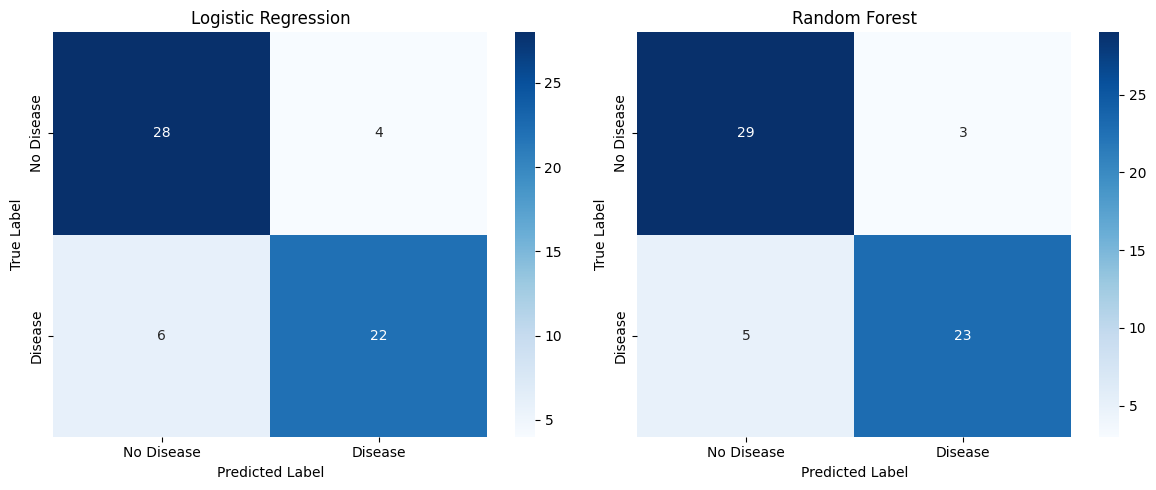

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(1,2, figsize=(12,5))

cm_log = confusion_matrix(y_test, y_pred_log)

# Logistic Regression
sns.heatmap(cm_log, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Disease","Disease"],
            yticklabels=["No Disease","Disease"], ax=ax[0])

ax[0].set_title("Logistic Regression")
ax[0].set_xlabel("Predicted Label")
ax[0].set_ylabel("True Label")


# Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Disease","Disease"],
            yticklabels=["No Disease","Disease"], ax=ax[1])

ax[1].set_title("Random Forest")
ax[1].set_xlabel("Predicted Label")
ax[1].set_ylabel("True Label")

plt.tight_layout()
plt.show()

**The confusion matrices** show how well each model classified patients. *Logistic Regression* correctly predicted most cases but made a few mistakes, especially missing some patients with heart disease. *Random Forest* performed slightly better, with fewer errors in both healthy and sick patients, making it the more reliable model for this dataset.

In [ ]:
from sklearn.metrics import roc_auc_score

log_auc = roc_auc_score(y_test, log_reg.predict_proba(x_test_scaled)[:,1])
rf_auc = roc_auc_score(y_test, rf_model.predict_proba(x_test)[:,1])

print("Logistic Regression ROC-AUC:", log_auc)
print("Random Forest ROC-AUC:", rf_auc)


Logistic Regression ROC-AUC: 0.9497767857142857
Random Forest ROC-AUC: 0.9453125


Both models perform excellently at distinguishing patients with and without heart disease,

with Logistic Regression achieving ROC-AUC 0.95 and Random Forest 0.95, indicating strong classification ability.

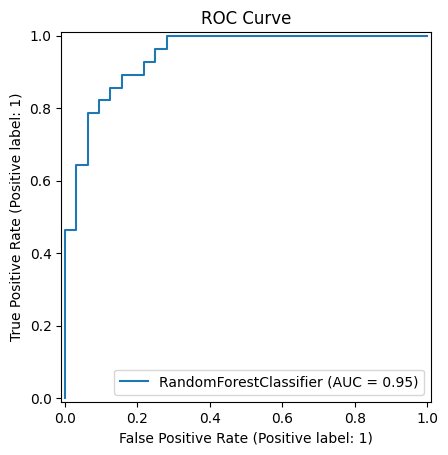

In [ ]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(rf_model, x_test, y_test)
plt.title("ROC Curve")
plt.show()

**The ROC curve** illustrates the trade-off between the true positive rate and false positive rate for different classification thresholds. The Random Forest model achieved a ROC-AUC score of 0.95, indicating strong discriminative performance in distinguishing between patients with and without heart disease.

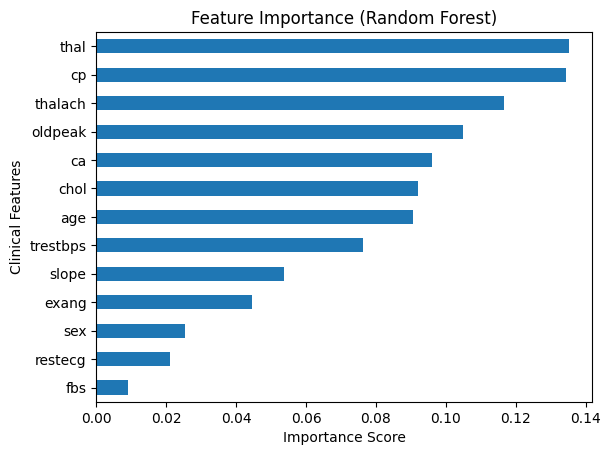

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

importance = rf_model.feature_importances_
features = x.columns

feat_imp = pd.Series(importance, index=features)
feat_imp.sort_values().plot(kind='barh')

plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance Score")
plt.ylabel("Clinical Features")
plt.show()

**The feature importance plot** derived from the Random Forest model highlights the most influential variables for predicting heart disease. Variables such as **chest pain type (cp)**, and **thal (thalassemia type)** have the highest impact, followed by **maximum heart rate (thalach)**, and **ST depression (oldpeak)** show higher importance scores, indicating they contribute strongly to the model's decision process.

In [ ]:
feature_names = [
    "age","sex","cp","trestbps","chol","fbs",
    "restecg","thalach","exang","oldpeak",
    "slope","ca","thal"
]

new_patient = [54, 1, 3, 130, 250, 0, 1, 150, 0, 1.2, 2, 0, 3]

patient_df = pd.DataFrame([new_patient], columns=feature_names)

prediction = rf_model.predict(patient_df)

if prediction[0] == 1:
    print("Patient likely HAS heart disease")
else:
    print("Patient likely does NOT have heart disease")

Patient likely does NOT have heart disease


In [ ]:
import joblib

model_path_rf = "/content/drive/MyDrive/Colab Notebooks/CodeAlpha/CodeAlpha_DiseasePrediction/random_forest_model.pkl"
model_path_log_reg = "/content/drive/MyDrive/Colab Notebooks/CodeAlpha/CodeAlpha_DiseasePrediction/digit_model.h5"
joblib.dump(rf_model, model_path_rf)
joblib.dump(log_reg, model_path_log_reg)

['/content/drive/MyDrive/Colab Notebooks/CodeAlpha/CodeAlpha_DiseasePrediction/logistic_model.pkl']

In [ ]:
!ls "/content/drive/MyDrive/Colab Notebooks/CodeAlpha/CodeAlpha_DiseasePrediction"

data  disease_prediction.ipynb	logistic_model.pkl  random_forest_model.pkl
